# **Pet Image Classification using ConvNeXt-Tiny**
**Author:** John Walsh      
**Date:** 18th of March 2026        
**Student ID:** 20245424      
**Code executes to the end without errors:** Yes      
**Source used for guidance:** *Hands-On Machine Learning with Scikit-Learn and PyTorch*

# **Data Preprocessing:**


**Imports and Constants:**

In [ ]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
import torch
import torch.nn as nn
from collections import Counter
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import copy
import gc

# Constants needed to reproduce results
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Set up GPU. I am running this on an RTX 4060 with 8GB of VRAM.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print the gpu out
print(f"Using device: {torch.cuda.get_device_name(device)}")

# Create a config dictionary to store hyperparameters and other settings
CONFIG = {
    # pretrained ConvNeXt-Tiny takes images of size 224x224.
    "img_size": 224,
    # 32 was too high :(
    "batch_size": 16,
    # workers for data loading. My GPU server has an i9 so I am using 8 threads.
    "num_workers": 8,
    "epochs": 8,
    "lr": 1e-4,
    "weight_decay": 1e-4,
    "n_splits": 5
}

Using device: NVIDIA GeForce RTX 4060


**Load the Dataset:**

In [ ]:

# Load the Oxford-IIIT Pet dataset without transformations to look at raw images
raw_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    download=True
)

print(f"Number of images in trainval split: {len(raw_dataset)}")

# Extract labels
labels = [raw_dataset[i][1] for i in range(len(raw_dataset))]
labels = np.array(labels)

# Count the number of samples per class
class_counts = Counter(labels)
print("Class distribution:")
for class_id, count in class_counts.items():
    print(f"Class {class_id}: {count} samples")

Number of images in trainval split: 3680
Class distribution:
Class 0: 100 samples
Class 1: 100 samples
Class 2: 100 samples
Class 3: 100 samples
Class 4: 100 samples
Class 5: 100 samples
Class 6: 100 samples
Class 7: 96 samples
Class 8: 100 samples
Class 9: 100 samples
Class 10: 100 samples
Class 11: 93 samples
Class 12: 96 samples
Class 13: 100 samples
Class 14: 100 samples
Class 15: 100 samples
Class 16: 100 samples
Class 17: 100 samples
Class 18: 100 samples
Class 19: 100 samples
Class 20: 100 samples
Class 21: 100 samples
Class 22: 96 samples
Class 23: 100 samples
Class 24: 100 samples
Class 25: 100 samples
Class 26: 100 samples
Class 27: 100 samples
Class 28: 100 samples
Class 29: 100 samples
Class 30: 100 samples
Class 31: 100 samples
Class 32: 99 samples
Class 33: 100 samples
Class 34: 100 samples
Class 35: 100 samples
Class 36: 100 samples


**Visualise Images:**

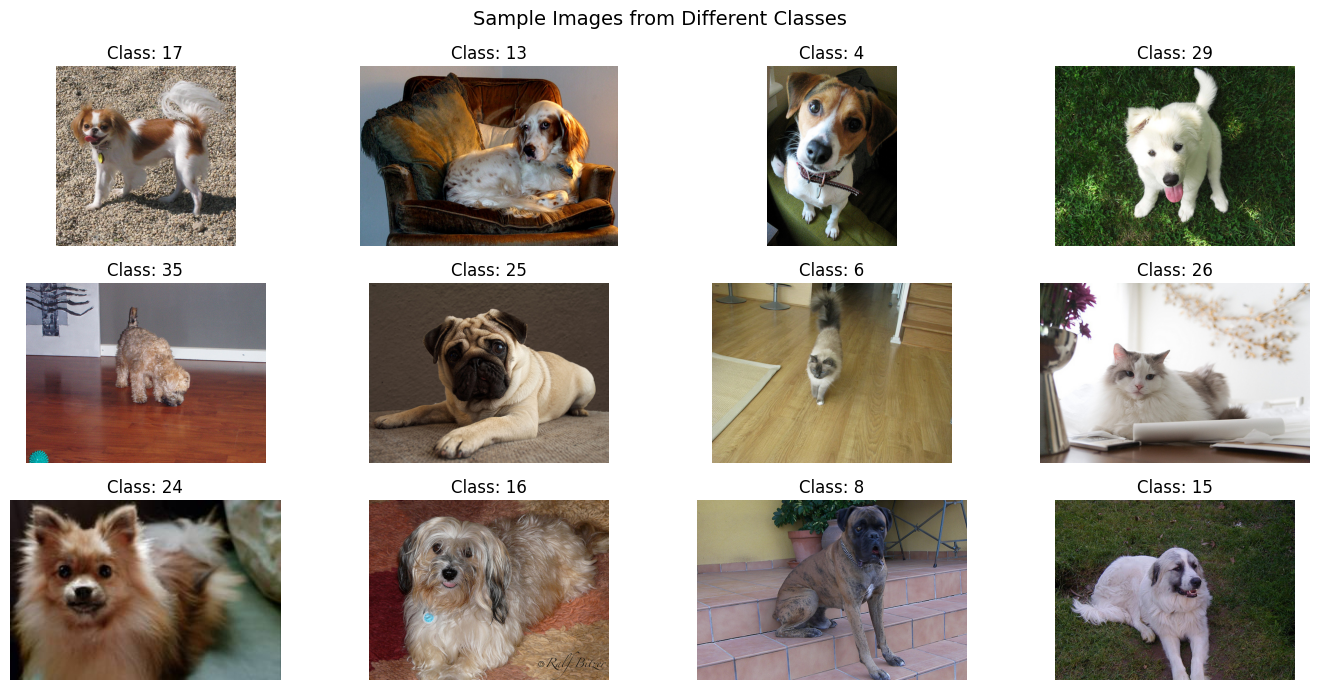

In [ ]:
# Plot a few images from different classes of the dataset to visualise
num_images_to_show = 12

# Get unique class labels
unique_classes = np.unique(labels)

# Randomly choose a subset of different classes
chosen_classes = np.random.choice(unique_classes, size=num_images_to_show, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(14, 7))
axes = axes.flatten()

for i, class_id in enumerate(chosen_classes):

    # Find all dataset indices belonging to this class
    class_indices = np.where(labels == class_id)[0]

    # Randomly pick one image index from that class
    chosen_index = np.random.choice(class_indices)

    image, label = raw_dataset[chosen_index]

    axes[i].imshow(image)
    axes[i].set_title(f"Class: {label}")
    axes[i].axis("off")

plt.suptitle("Sample Images from Different Classes", fontsize=14)
plt.tight_layout()
plt.show()


**Plot the class distribution:**

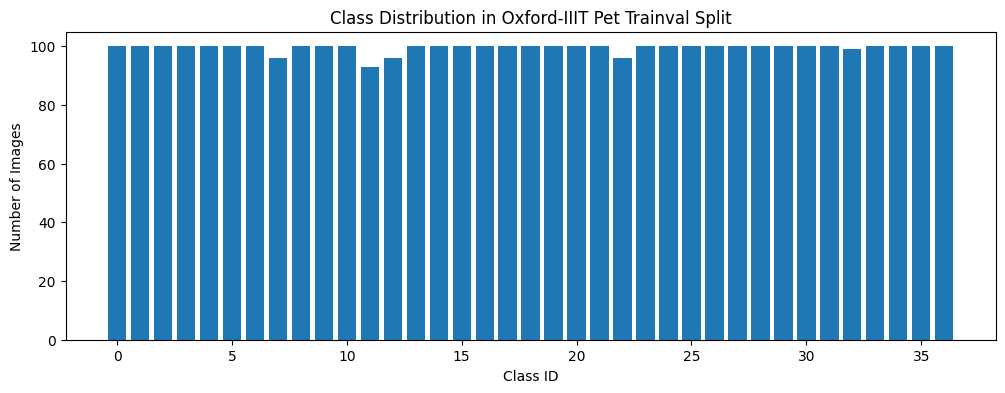

Min samples in a class: 93
Max samples in a class: 100


In [ ]:
class_counts = Counter(labels)

plt.figure(figsize=(12, 4))
plt.bar(class_counts.keys(), class_counts.values())
plt.xlabel("Class ID")
plt.ylabel("Number of Images")
plt.title("Class Distribution in Oxford-IIIT Pet Trainval Split")
plt.show()

print(f"Min samples in a class: {min(class_counts.values())}")
print(f"Max samples in a class: {max(class_counts.values())}")

**Create image transformations:**

In [ ]:
# Since ConvNeXt-Tiny was designed for imagenet we should use the same transformations as imagenet.

# get the default pretrained convnext transformations from torchvision.
weights = models.ConvNeXt_Tiny_Weights.DEFAULT

# get the standard transformations for convnext.
val_transform = weights.transforms()

# get the mean and std values for imagenet normalisation.
imagenet_mean = val_transform.mean
imagenet_std = val_transform.std

# Include Augmentations and normalisation for convnext
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

# For validation and test sets we only want to resize and normalise
# This is just so validation reflects real performance
val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std)
])

**Set up Cross Fold Validation:**

In [ ]:
# The Oxford III pet dataset is small enough to use stratified k-fold cross validation effectively
# without being too expensive.

skf = StratifiedKFold(
    n_splits=CONFIG["n_splits"],
    shuffle=True,
    random_state=SEED
)

# Store all folds as a list of (train_idx, val_idx)
folds = list(skf.split(np.arange(len(labels)), labels))

print(f"Created {len(folds)} stratified folds.\n")

for fold_idx, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {fold_idx + 1}: train = {len(train_idx)}, val = {len(val_idx)}")

Created 5 stratified folds.

Fold 1: train = 2944, val = 736
Fold 2: train = 2944, val = 736
Fold 3: train = 2944, val = 736
Fold 4: train = 2944, val = 736
Fold 5: train = 2944, val = 736


**Create a Base Dataset for Training and Validation:**

In [ ]:
# This dataset has augmentaions for training
train = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=train_transform,
    download=False
)

# This dataset has no augmentations for validation, only resizing and normalisation.
# Best practice for unseen data.
val = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=val_transform,
    download=False
)

**Function for Returning a Dataloader for a Fold:**

In [ ]:
def get_dataloaders(train_ds, val_ds, fold_number, batch_size=CONFIG["batch_size"], num_workers=CONFIG["num_workers"]):
    """
    Returns the dataloaders for a given fold number and returns the train and val indices for that fold for later analysis.
    """
    train_idx, val_idx = folds[fold_number]

    train_dataset = Subset(train_ds, train_idx)
    val_dataset = Subset(val_ds, val_idx)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=torch.cuda.is_available()
    )

    return train_loader, val_loader, train_idx, val_idx


train_loader, val_loader, train_idx, val_idx = get_dataloaders(train, val, fold_number=0)
print(f"Fold 1 training samples: {len(train_idx)}")
print(f"Fold 1 validation samples: {len(val_idx)}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")



# Quick test
print("\n")
images, labels_batch = next(iter(train_loader))
print(f"Image batch shape: {images.shape}")
print(f"Label batch shape: {labels_batch.shape}")
print(f"Image dtype: {images.dtype}")
print(f"Label dtype: {labels_batch.dtype}")

Fold 1 training samples: 2944
Fold 1 validation samples: 736
Training batches: 184
Validation batches: 46


Image batch shape: torch.Size([16, 3, 224, 224])
Label batch shape: torch.Size([16])
Image dtype: torch.float32
Label dtype: torch.int64


# **Model Setup:**

**CONVNEXT-TINY Model Definition:**

In [ ]:
def build_convnext_tiny(num_classes):
    """
    Create the ConvNext-Tiny model with transfer learning pretrained on ImageNet and replace the final classifier.
    """

    # Get the default pretrained convnext weights from torchvision.
    weights = models.ConvNeXt_Tiny_Weights.DEFAULT
    model = models.convnext_tiny(weights=weights)

    # Replace the final Linear layer so the model predicts our pet classes.
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)

    return model

In [ ]:
# Get the number of classes in the dataset
num_classes = len(np.unique(labels))

# instantiate the model on the gpu
model = build_convnext_tiny(num_classes=num_classes).to(device)
print(model)

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

**Define Loss Function and Optimiser:**

In [ ]:
# Cross Entropy for multiclass classification.
loss_fn = nn.CrossEntropyLoss()

# Adam for adaptive learning rate optimisation
optimiser = torch.optim.Adam(
    model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

print(f"Loss function: {loss_fn}")
print(f"Optimiser: {optimiser}")

Loss function: CrossEntropyLoss()
Optimiser: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


# **Training and Evaluation Functions:**

In [ ]:
def compute_metrics(y_true, y_pred):
    """Function to get macro averaged metrics for multi-class classification."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }


def train_one_epoch(model, dataloader, loss_fn, optimiser):
    """Trains the model for one epoch and returns the average loss and metrics."""
    # switch on training mode
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    # move images to gpu
    for images, labels in dataloader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimiser.zero_grad()
        logits = model(images)
        loss = loss_fn(logits, labels)

        # propagate gradients and update weights
        loss.backward()
        optimiser.step()

        # accumulate loss and predictions for metrics
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        # store predictions and labels for metrics calculation at the end of the epoch
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # calculate average loss and metrics for the epoch
    epoch_loss = running_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss
    return metrics

# this decorator disables gradient calculations. not needed for evaluation.
@torch.no_grad()
def evaluate_one_epoch(model, dataloader, loss_fn):
    """Evaluates the model for one epoch and returns the average loss and metrics."""
    # switch on evaluation mode
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    # move images to gpu
    for images, labels in dataloader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        # No backpropagation or weight updates during evaluation
        #  just forward pass and metric calculation.
        logits = model(images)
        loss = loss_fn(logits, labels)

        # accumulate loss and predictions for metrics
        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(logits, dim=1)

        # store predictions and labels for metrics calculation at the end of the epoch
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    # calculate average loss and metrics for the epoch
    epoch_loss = running_loss / len(dataloader.dataset)
    metrics = compute_metrics(all_labels, all_preds)
    metrics["loss"] = epoch_loss
    return metrics


def train_model(model, train_loader, val_loader, loss_fn, optimiser, epochs):
    """Trains the model for a given number of epochs and returns the history of training and validation metrics."""
    history = {"train": [], "val": []}

    for epoch in range(epochs):
        train_metrics = train_one_epoch(model, train_loader, loss_fn, optimiser)
        val_metrics = evaluate_one_epoch(model, val_loader, loss_fn)

        history["train"].append(train_metrics)
        history["val"].append(val_metrics)

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Train Loss: {train_metrics['loss']:.4f} Acc: {train_metrics['accuracy']:.4f} | "
              f"Val Loss: {val_metrics['loss']:.4f} Acc: {val_metrics['accuracy']:.4f}")

    return history


def plot_experiment_results(history, title_prefix="Experiment"):
    """Function to plot the training and validation metrics over epochs for loss, accuracy and f1 score."""

    # Get the number of epochs to use for the x axis
    epochs = range(1, len(history["train"]) + 1)

    # Pull out the metrics from the history dictionary we saved during training
    train_loss = [m["loss"] for m in history["train"]]
    val_loss = [m["loss"] for m in history["val"]]

    train_acc = [m["accuracy"] for m in history["train"]]
    val_acc = [m["accuracy"] for m in history["val"]]

    # Using macro f1 because we have 37 classes and it balances out the scores
    train_f1 = [m["f1"] for m in history["train"]]
    val_f1 = [m["f1"] for m in history["val"]]

    # Set up a 1x3 grid so the plots are side-by-side and fit nicely in the report
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"{title_prefix} - Training vs Validation Metrics", fontsize=16)

    # Plot 1: Cross Entropy Loss. This is the main one to check for overfitting.
    axes[0].plot(epochs, train_loss, 'b-', label='Train Loss')
    axes[0].plot(epochs, val_loss, 'r--', label='Val Loss')
    axes[0].set_title('Loss Over Epochs')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Accuracy
    axes[1].plot(epochs, train_acc, 'b-', label='Train Accuracy')
    axes[1].plot(epochs, val_acc, 'r--', label='Val Accuracy')
    axes[1].set_title('Accuracy Over Epochs')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Plot 3: F1 Score
    axes[2].plot(epochs, train_f1, 'b-', label='Train F1 (Macro)')
    axes[2].plot(epochs, val_f1, 'r--', label='Val F1 (Macro)')
    axes[2].set_title('F1 Score Over Epochs')
    axes[2].set_xlabel('Epochs')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(True, linestyle='--', alpha=0.7)

    # clean up the layout so labels don't overlap
    plt.tight_layout()
    plt.show()

# **Experiments and Results:**

**Experiment 1: Geron mentions a library called Optuna in his book Hands on Machine Learning that searches for optimal hyperparameters. This is an implementation of it looking for optimal learning rates and weight decay values.**

In [ ]:
def objective(trial):
    """An Optuna search for optimal learning rate and weight decay.
    Done on the first K fold."""

    # give values to try for learning rate and weight decay
    lr = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)

    # instantiate a new model
    trial_model = build_convnext_tiny(num_classes).to(device)

    # Give the optimiser the suggested params
    trial_optimiser = torch.optim.Adam(trial_model.parameters(), lr=lr, weight_decay=weight_decay)

    # I am only doing it on fold 0 because I have 8GB VRAM, anymore would be a push
    t_loader, v_loader, _, _ = get_dataloaders(train, val, fold_number=0)

    # Quick test for 3 epochs to see if the values work well
    for epoch in range(3):
        train_one_epoch(trial_model, t_loader, loss_fn, trial_optimiser)
        val_metrics = evaluate_one_epoch(trial_model, v_loader, loss_fn)

    # Record results to see if we need to prune bad trials early
    trial.report(val_metrics["accuracy"], epoch)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    # Clear memory
    del trial_model, trial_optimiser
    torch.cuda.empty_cache()
    gc.collect()

    # We want optuna to maximise this accuracy score
    return val_metrics["accuracy"]

# instantiate optuna experiment and run with 10 trials
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10)

print("\nBest Trial Params found by Optuna:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# update the config to use the best parameters
CONFIG["lr"] = study.best_trial.params["lr"]
CONFIG["weight_decay"] = study.best_trial.params["weight_decay"]

[I 2026-03-15 18:49:58,615] A new study created in memory with name: no-name-299150c4-8e1c-4519-bf4c-768a81614dd4
[I 2026-03-15 18:51:23,825] Trial 0 finished with value: 0.7445652173913043 and parameters: {'lr': 0.0007343367095565728, 'weight_decay': 0.0005873421865442072}. Best is trial 0 with value: 0.7445652173913043.
[I 2026-03-15 18:52:49,453] Trial 1 finished with value: 0.9470108695652174 and parameters: {'lr': 0.00010695974955354008, 'weight_decay': 2.1729357914911374e-05}. Best is trial 1 with value: 0.9470108695652174.
[I 2026-03-15 18:54:15,090] Trial 2 finished with value: 0.8179347826086957 and parameters: {'lr': 0.0002309915960702787, 'weight_decay': 0.003493098944819453}. Best is trial 1 with value: 0.9470108695652174.
[I 2026-03-15 18:55:40,567] Trial 3 finished with value: 0.8519021739130435 and parameters: {'lr': 0.000496322457465423, 'weight_decay': 0.0001479622925176176}. Best is trial 1 with value: 0.9470108695652174.
[I 2026-03-15 18:57:06,060] Trial 4 finished w


Best Trial Params found by Optuna:
  lr: 0.00010695974955354008
  weight_decay: 2.1729357914911374e-05


**Plot the model results with the optimal parameters:**

Epoch 1/8 | Train Loss: 1.3802 Acc: 0.7412 | Val Loss: 0.3145 Acc: 0.9239
Epoch 2/8 | Train Loss: 0.2358 Acc: 0.9565 | Val Loss: 0.2142 Acc: 0.9334
Epoch 3/8 | Train Loss: 0.1046 Acc: 0.9796 | Val Loss: 0.1771 Acc: 0.9484
Epoch 4/8 | Train Loss: 0.0713 Acc: 0.9844 | Val Loss: 0.1855 Acc: 0.9457
Epoch 5/8 | Train Loss: 0.0460 Acc: 0.9922 | Val Loss: 0.1995 Acc: 0.9375
Epoch 6/8 | Train Loss: 0.0633 Acc: 0.9847 | Val Loss: 0.2423 Acc: 0.9361
Epoch 7/8 | Train Loss: 0.0481 Acc: 0.9895 | Val Loss: 0.1683 Acc: 0.9497
Epoch 8/8 | Train Loss: 0.0143 Acc: 0.9976 | Val Loss: 0.2347 Acc: 0.9402


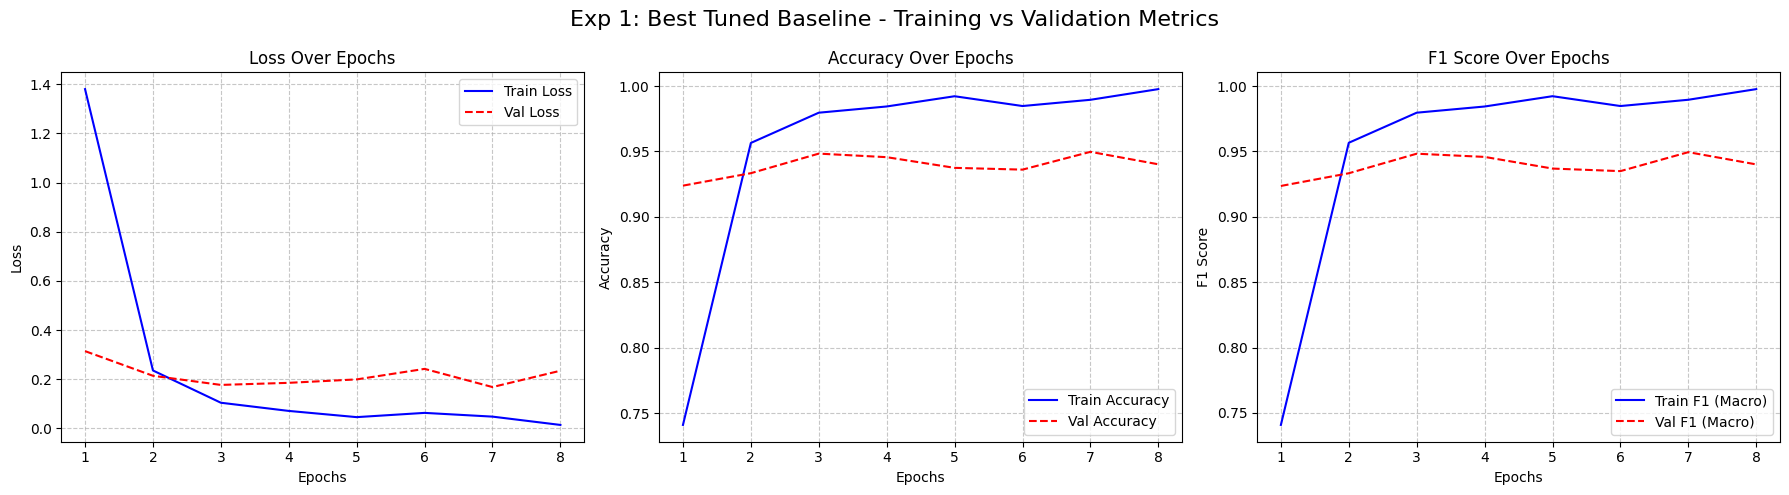

11124

In [ ]:
# Build a fresh model
best_tuned_model = build_convnext_tiny(num_classes).to(device)

# Use new optimal parameters Optuna just found
optimiser_best = torch.optim.Adam(
    best_tuned_model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

# Train on Fold 0 for the full number of epochs
t_loader, v_loader, _, _ = get_dataloaders(train, val, fold_number=0)
best_tuned_history = train_model(best_tuned_model, t_loader, v_loader, loss_fn, optimiser_best, epochs=CONFIG["epochs"])

# plot it
plot_experiment_results(best_tuned_history, title_prefix="Exp 1: Best Tuned Baseline")

del best_tuned_model, optimiser_best
torch.cuda.empty_cache()
gc.collect()

**Experiment 2: Test if freezing the feature extractor is better than fine tuning the whole model.**

Training Frozen Model for 8 epochs...
Epoch 1/8 | Train Loss: 3.0739 Acc: 0.4484 | Val Loss: 2.4691 Acc: 0.7976
Epoch 2/8 | Train Loss: 2.0399 Acc: 0.8488 | Val Loss: 1.5544 Acc: 0.8682
Epoch 3/8 | Train Loss: 1.3064 Acc: 0.9018 | Val Loss: 0.9841 Acc: 0.8967
Epoch 4/8 | Train Loss: 0.8788 Acc: 0.9273 | Val Loss: 0.6833 Acc: 0.9158
Epoch 5/8 | Train Loss: 0.6404 Acc: 0.9307 | Val Loss: 0.5219 Acc: 0.9253
Epoch 6/8 | Train Loss: 0.5091 Acc: 0.9358 | Val Loss: 0.4252 Acc: 0.9375
Epoch 7/8 | Train Loss: 0.4154 Acc: 0.9463 | Val Loss: 0.3629 Acc: 0.9416
Epoch 8/8 | Train Loss: 0.3566 Acc: 0.9507 | Val Loss: 0.3193 Acc: 0.9443


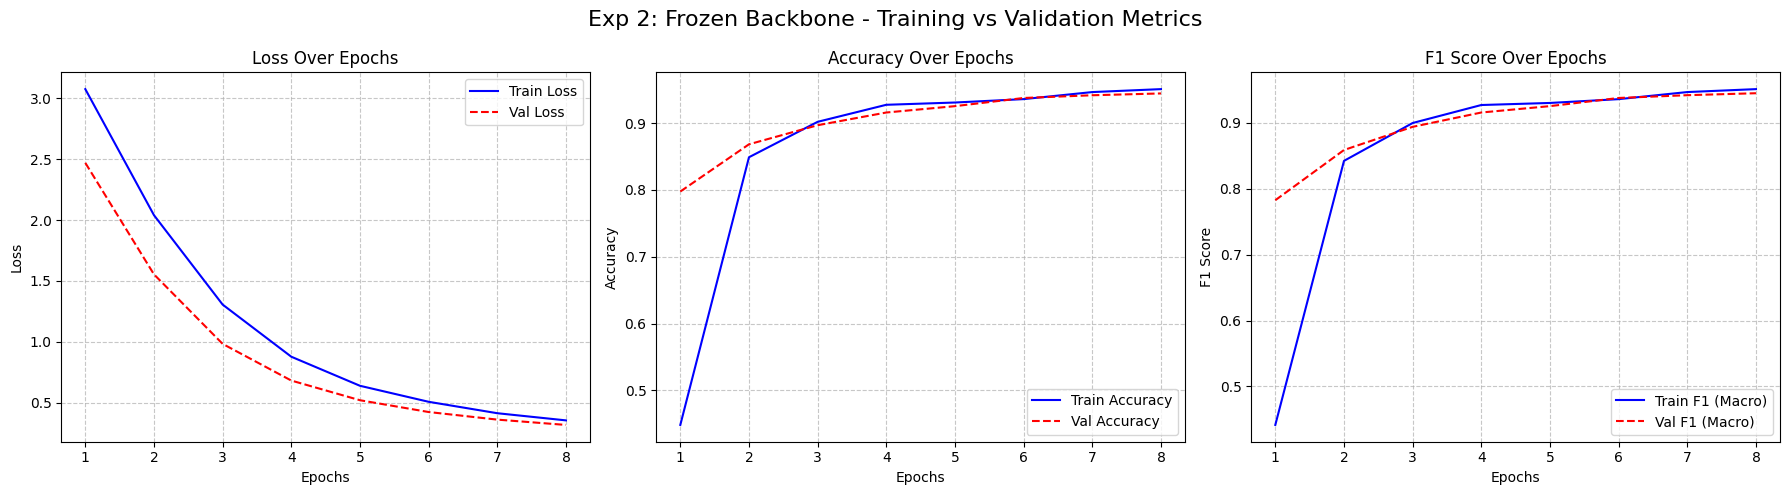

11561

In [ ]:
# instantiate a new model
frozen_model = build_convnext_tiny(num_classes).to(device)

# Loop through the feature extractor layers and turn off gradients
for param in frozen_model.features.parameters():
    param.requires_grad = False

# Make sure the weights passed to Adam are allowed to learn
trainable_params = [p for p in frozen_model.parameters() if p.requires_grad]
optimiser_frozen = torch.optim.Adam(
    trainable_params,
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

# train on fold 0 with full epochs and with a frozen backbone
t_loader, v_loader, _, _ = get_dataloaders(train, val, fold_number=0)
print(f"Training Frozen Model for {CONFIG['epochs']} epochs...")

frozen_history = train_model(
    frozen_model,
    t_loader,
    v_loader,
    loss_fn,
    optimiser_frozen,
    epochs=CONFIG["epochs"]
)

# plot experiment
plot_experiment_results(frozen_history, title_prefix="Exp 2: Frozen Backbone")

# clear memory
del frozen_model, optimiser_frozen
torch.cuda.empty_cache()
gc.collect()

**Experiment 3: The last experiment I am going to do is test training with no data augmentation and see what happens**

Training Unaugmented Model for 8 epochs...
Epoch 1/8 | Train Loss: 1.3506 Acc: 0.7442 | Val Loss: 0.3107 Acc: 0.9212
Epoch 2/8 | Train Loss: 0.1823 Acc: 0.9667 | Val Loss: 0.1803 Acc: 0.9511
Epoch 3/8 | Train Loss: 0.0624 Acc: 0.9905 | Val Loss: 0.2050 Acc: 0.9402
Epoch 4/8 | Train Loss: 0.0410 Acc: 0.9942 | Val Loss: 0.2556 Acc: 0.9280
Epoch 5/8 | Train Loss: 0.0434 Acc: 0.9901 | Val Loss: 0.2349 Acc: 0.9185
Epoch 6/8 | Train Loss: 0.0270 Acc: 0.9959 | Val Loss: 0.2035 Acc: 0.9443
Epoch 7/8 | Train Loss: 0.0372 Acc: 0.9935 | Val Loss: 0.1852 Acc: 0.9457
Epoch 8/8 | Train Loss: 0.0107 Acc: 0.9986 | Val Loss: 0.3158 Acc: 0.9130


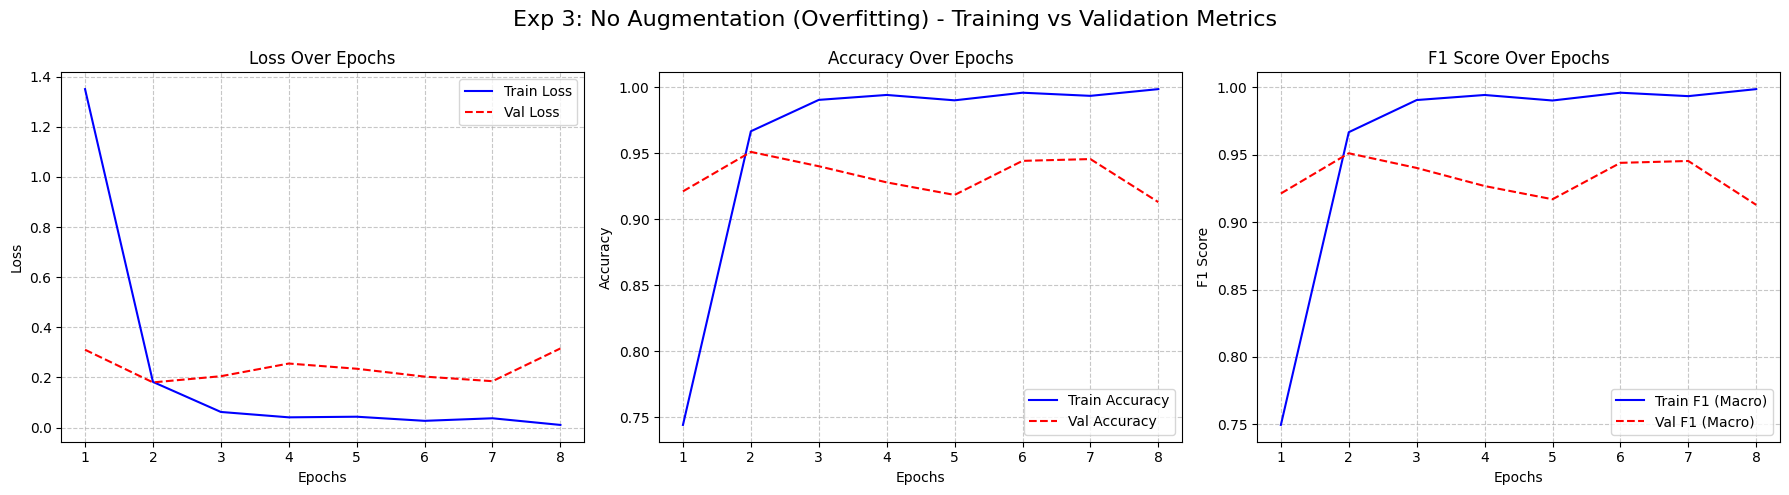

11124

In [ ]:
# pass validation to both so the model will just see the exact same static images.
# with no extra augmentations to help with generalisation
no_aug_t_loader, no_aug_v_loader, _, _ = get_dataloaders(val, val, fold_number=0)

# instantiate a new model
no_aug_model = build_convnext_tiny(num_classes).to(device)

# Train on fold 0
optimiser_no_aug = torch.optim.Adam(
    no_aug_model.parameters(),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)

print(f"Training Unaugmented Model for {CONFIG['epochs']} epochs...")

no_aug_history = train_model(
    no_aug_model,
    no_aug_t_loader,
    no_aug_v_loader,
    loss_fn,
    optimiser_no_aug,
    epochs=CONFIG["epochs"]
)
# plot it
plot_experiment_results(no_aug_history, title_prefix="Exp 3: No Augmentation (Overfitting)")

# clear memory
del no_aug_model, optimiser_no_aug
torch.cuda.empty_cache()
gc.collect()

# **Final Evaluation:**

**Given all the experiment results, I am now going to train and evaluate across with the optimal learning rate and weight decay and with a frozen backbone**

In [ ]:
# List to store the final metrics dictionaries generated by compute_metrics
fold_results = []

for fold in range(CONFIG["n_splits"]):
    print(f"\n--- Training Fold {fold + 1}/{CONFIG['n_splits']} ---")

    # Get the loaders for this specific fold
    t_loader, v_loader, _, _ = get_dataloaders(train, val, fold_number=fold)

    # Build model and freeze the backbone since we say it cause the model to generalise better to unseen data
    fold_model = build_convnext_tiny(num_classes).to(device)
    for param in fold_model.features.parameters():
        param.requires_grad = False

    # Same as 2. give the optimiser the unfrozen classifier weights
    trainable_params = [p for p in fold_model.parameters() if p.requires_grad]
    fold_optimiser = torch.optim.Adam(
        trainable_params,
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )

    # Train the model
    fold_history = train_model(
        fold_model,
        t_loader,
        v_loader,
        loss_fn,
        fold_optimiser,
        epochs=CONFIG["epochs"]
    )

    # Grab the final epochs validation metrics dictionary
    final_val_metrics = fold_history["val"][-1]
    fold_results.append(final_val_metrics)

    print(f"Fold {fold + 1} Final Val Accuracy: {final_val_metrics['accuracy']:.4f}")

    # Clear memory
    del fold_model, fold_optimiser
    torch.cuda.empty_cache()
    gc.collect()

# Get the mean of all the metrics across all folds
avg_accuracy = np.mean([res["accuracy"] for res in fold_results])
avg_f1 = np.mean([res["f1"] for res in fold_results])
avg_precision = np.mean([res["precision"] for res in fold_results])
avg_recall = np.mean([res["recall"] for res in fold_results])

print(f"Accuracy:  {avg_accuracy}")
print(f"F1 Score:  {avg_f1}")
print(f"Precision: {avg_precision}")
print(f"Recall:    {avg_recall}")


--- Training Fold 1/5 ---
Epoch 1/8 | Train Loss: 3.1120 Acc: 0.3978 | Val Loss: 2.4960 Acc: 0.7690
Epoch 2/8 | Train Loss: 2.0881 Acc: 0.8298 | Val Loss: 1.5841 Acc: 0.8954
Epoch 3/8 | Train Loss: 1.3522 Acc: 0.8981 | Val Loss: 1.0062 Acc: 0.9266
Epoch 4/8 | Train Loss: 0.8989 Acc: 0.9263 | Val Loss: 0.6970 Acc: 0.9293
Epoch 5/8 | Train Loss: 0.6655 Acc: 0.9361 | Val Loss: 0.5319 Acc: 0.9348
Epoch 6/8 | Train Loss: 0.5198 Acc: 0.9348 | Val Loss: 0.4317 Acc: 0.9443
Epoch 7/8 | Train Loss: 0.4289 Acc: 0.9440 | Val Loss: 0.3681 Acc: 0.9497
Epoch 8/8 | Train Loss: 0.3600 Acc: 0.9521 | Val Loss: 0.3235 Acc: 0.9497
Fold 1 Final Val Accuracy: 0.9497

--- Training Fold 2/5 ---
Epoch 1/8 | Train Loss: 3.0701 Acc: 0.4263 | Val Loss: 2.4339 Acc: 0.8043
Epoch 2/8 | Train Loss: 2.0501 Acc: 0.8427 | Val Loss: 1.5237 Acc: 0.8981
Epoch 3/8 | Train Loss: 1.3236 Acc: 0.9018 | Val Loss: 0.9639 Acc: 0.9212
Epoch 4/8 | Train Loss: 0.8832 Acc: 0.9195 | Val Loss: 0.6686 Acc: 0.9334
Epoch 5/8 | Train Loss: 